In [1]:
#import relevant libraries
import os

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import dabest

import NLCLIMB_asyn
import NLMATH_asyn

#NOTE: SUPPRESSES WARNINGS!

import warnings

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 18.03it/s]

Numba compilation complete!


In [2]:
metricframe_cache = {}

def metricframe(genotype):
    if genotype in metricframe_cache:
        return metricframe_cache[genotype].copy()

    df = pd.read_csv(openPath + genotype + ".csv")
    df = df.drop(df.columns[[0]], axis = 1)   #the compiled CSVs carry an index column
    df = NLCLIMB_asyn.generation(df, genotype)
    #the fly filters run on the full 30 s, so the same flies are kept as in the 30 s notebook;
    #only the metrics are cut to the first `window` seconds of each phase
    df = df[df.Seconds < window].reset_index(drop=True)

    cy = NLMATH_asyn.calcgraph(df, "Y.*")
    cv = NLMATH_asyn.calcgraph(df, "Velocity.*")
    cb = NLMATH_asyn.calcgraph(NLMATH_asyn.boutspeed(df), "BSpeed.*")
    si = NLMATH_asyn.straightnessindexmeter(df, genotype)

    out = pd.DataFrame()
    for n in phase:
        h = cy[cy.ExperimentState == n].iloc[:, 2:].mean(axis=0)
        v = cv[cv.ExperimentState == n].iloc[:, 2:].mean(axis=0)
        b = cb[cb.ExperimentState == n].iloc[:, 2:].mean(axis=0)
        s = si[si.ExperimentState == n]["averagestraightnessindex"]

        t = pd.DataFrame({"Height": h.values, "Speed": v.values,
                          "BSpeed": b.values, "SI": s.values})
        t["fly"] = [genotype + "_" + c.rsplit("_", 1)[-1] for c in h.index]
        t["Phase"] = n
        out = pd.concat([out, t])

    out = out.reset_index(drop=True)
    metricframe_cache[genotype] = out

    return out.copy()


def arms(cross, age):
    #the pooled parental controls and the experimental, or None where there is no comparison to make.
    #Only w1118 x 95240 exists as a responder control, so most crosses pool down to the driver alone.
    if cross + "_" + age not in listofgenotypes:
        return None

    driver, responder = cross.split(" x ", 1)
    wts = [metricframe("w1118 x " + p + "_" + age) for p in [driver, responder]
           if "w1118 x " + p + "_" + age in listofgenotypes]
    if not wts:
        return None

    return pd.concat(wts).reset_index(drop=True), metricframe(cross + "_" + age)


def whole(frame, metric):
    #a fly the tracker lost in one phase cannot be paired, so it leaves the arm altogether
    return frame.dropna(subset = [metric]).groupby("fly").filter(lambda f: len(f) == len(phase))


#PLOT 1 - the three phases against each other, paired, first phase as the baseline.
#The first phase is the baseline of its own arm, so it carries an N but no contrast.

def phasecontrasts(metric):
    rows = []

    for cross in crosses:
        for age in ages:
            pair = arms(cross, age)
            if pair is None:
                continue

            #an arm too small to contrast takes its control down with it, so the panel stays empty
            both = [whole(f, metric) for f in pair]
            if min(f.fly.nunique() for f in both) < minflies:
                print(cross, age, "is", " against ".join(str(f.fly.nunique()) for f in both),
                      "flies, skipped")
                continue

            for kept, group in zip(both, ["Control", "Expt"]):
                kept = kept.assign(genre = kept["Phase"].map(phaselabels) + "_" + group)
                idx = tuple(phaselabels[n] + "_" + group for n in phase)
                res = dabest.load(data = kept, idx = idx, x = "genre", y = metric, paired = "baseline",
                                  id_col = "fly", resamples = resamples).hedges_g.results

                rows.append({"cross": cross, "block": age, "group": idx[0], "difference": np.nan,
                             "low": np.nan, "high": np.nan, "bootstraps": None,
                             "N": kept.fly.nunique()})

                for _, r in res.iterrows():
                    rows.append({"cross": cross, "block": age, "group": r["test"],
                                 "difference": r["difference"], "low": r["bca_low"], "high": r["bca_high"],
                                 "bootstraps": r["bootstraps"], "N": r["test_N"]})

    return pd.DataFrame(rows)


#PLOT 2 - one phase, control against experimental, at each age. Unpaired: the ages are
#different flies, so there is nothing to join up.

def agecontrasts(metric):
    rows = []

    for cross in crosses:
        data = pd.DataFrame()
        for age in ages:
            pair = arms(cross, age)
            if pair is None:
                continue

            wt, expt = (f.dropna(subset = [metric]) for f in pair)
            if wt.fly.nunique() < minflies or expt.fly.nunique() < minflies:
                print(cross, age, "is", wt.fly.nunique(), "against", expt.fly.nunique(), "flies, skipped")
                continue

            data = pd.concat([data, wt.assign(Group = "Control " + age),
                              expt.assign(Group = "Expt " + age)])

        if data.empty:
            continue

        for n in phase:
            here = data[data.Phase == n].reset_index(drop=True)
            idx = tuple((g, "Expt " + g.split(" ")[1]) for g in sorted(set(here.Group)) if g.startswith("Control"))
            res = dabest.load(data = here, idx = idx, x = "Group", y = metric,
                              resamples = resamples).hedges_g.results

            for _, r in res.iterrows():
                rows.append({"cross": cross, "block": n, "group": r["control"], "difference": np.nan,
                             "low": np.nan, "high": np.nan, "bootstraps": None, "N": r["control_N"]})
                rows.append({"cross": cross, "block": n, "group": r["test"],
                             "difference": r["difference"], "low": r["bca_low"], "high": r["bca_high"],
                             "bootstraps": r["bootstraps"], "N": r["test_N"]})

    return pd.DataFrame(rows)

def genotypelist(age):
    driver = crosses[0].split(" x ", 1)[0]
    responders = [c.split(" x ", 1)[1] for c in crosses]
    order = ["w1118 x " + driver] + ["w1118 x " + r for r in responders] + list(crosses)
    return [g for g in order if g + "_" + age in listofgenotypes]


def genotypecontrasts(metric):
    rows = []

    for age in ages:
        for g in genotypelist(age):
            kept = whole(metricframe(g + "_" + age), metric)
            if kept.fly.nunique() < minflies:
                print(g, age, "is", kept.fly.nunique(), "flies, skipped")
                continue

            kept = kept.assign(genre = kept["Phase"].map(phaselabels))
            idx = tuple(phaselabels[n] for n in phase)
            res = dabest.load(data = kept, idx = idx, x = "genre", y = metric, paired = "baseline",
                              id_col = "fly", resamples = resamples).hedges_g.results

            rows.append({"genotype": g, "block": age, "group": idx[0], "difference": np.nan,
                         "low": np.nan, "high": np.nan, "bootstraps": None, "N": kept.fly.nunique()})

            for _, r in res.iterrows():
                rows.append({"genotype": g, "block": age, "group": r["test"],
                             "difference": r["difference"], "low": r["bca_low"], "high": r["bca_high"],
                             "bootstraps": r["bootstraps"], "N": r["test_N"]})

    return pd.DataFrame(rows)


In [3]:
#initial file processing

laptop = "C:\\Users\\Nicole Lee\\"
homecomp = "C:\\Users\\user\\"
labcomp = "C:\\Users\\User\\"

path2 = "NUS Dropbox\\acclab\\Nicole M Lee\\"
openPath = homecomp + path2 + "PD\\Data Compilation\\"
savefiglocation = openPath + "images\\"

isExist = os.path.exists(savefiglocation)
if not isExist:
    os.makedirs(savefiglocation)

phase = ["First phase", "Second phase", "Third phase"]
ages = ["D10", "D20", "D30"]
metrics = ["Height", "Speed"]
rawlabels = {"Height": "Height climbed (mm)", "Speed": "Overall speed (mm/s)"}
phaselabels = {"First phase": "1st", "Second phase": "2nd", "Third phase": "3rd"}

#only the first this-many seconds of each phase go into the metrics
window = 10

#one row of panels per cross, and the smallest arm to take a contrast from. Edit these.
crosses = ["elav x 8146", "elav x 8147", "elav x 51375", "elav x 51376", "elav x 95240"]
minflies = 5

#the dabest default, so the intervals match the ones 4. Dabest draws
resamples = 5000

#each responder has a hue, shaded light to dark with age. The w1118 controls are grey. Edit these.
shades = {"blue":  {"D10": "#9ECAE1", "D20": "#4292C6", "D30": "#08306B"},
          "green": {"D10": "#90C590", "D20": "#228B22", "D30": "#114611"},
          "pink":  {"D10": "#FBB4C9", "D20": "#E7298A", "D30": "#91003F"}}
responderhue = {"8146": "blue", "95240": "blue", "51375": "green", "51376": "green", "8147": "pink"}
grey = "#808080"

def colourof(genotype, age):
    if genotype.startswith("w1118"):
        return grey
    return shades[responderhue[genotype.split(" x ")[-1]]][age]

listofgenotypes = sorted(f[:-4] for f in os.listdir(openPath) if f.endswith(".csv"))

print(len(listofgenotypes), "genotypes")

44 genotypes


elav x 8147 D30 is 4 flies, skipped
C:\Users\user\NUS Dropbox\acclab\Nicole M Lee\PD\Data Compilation\images\Forest_10s_phases_Height.svg


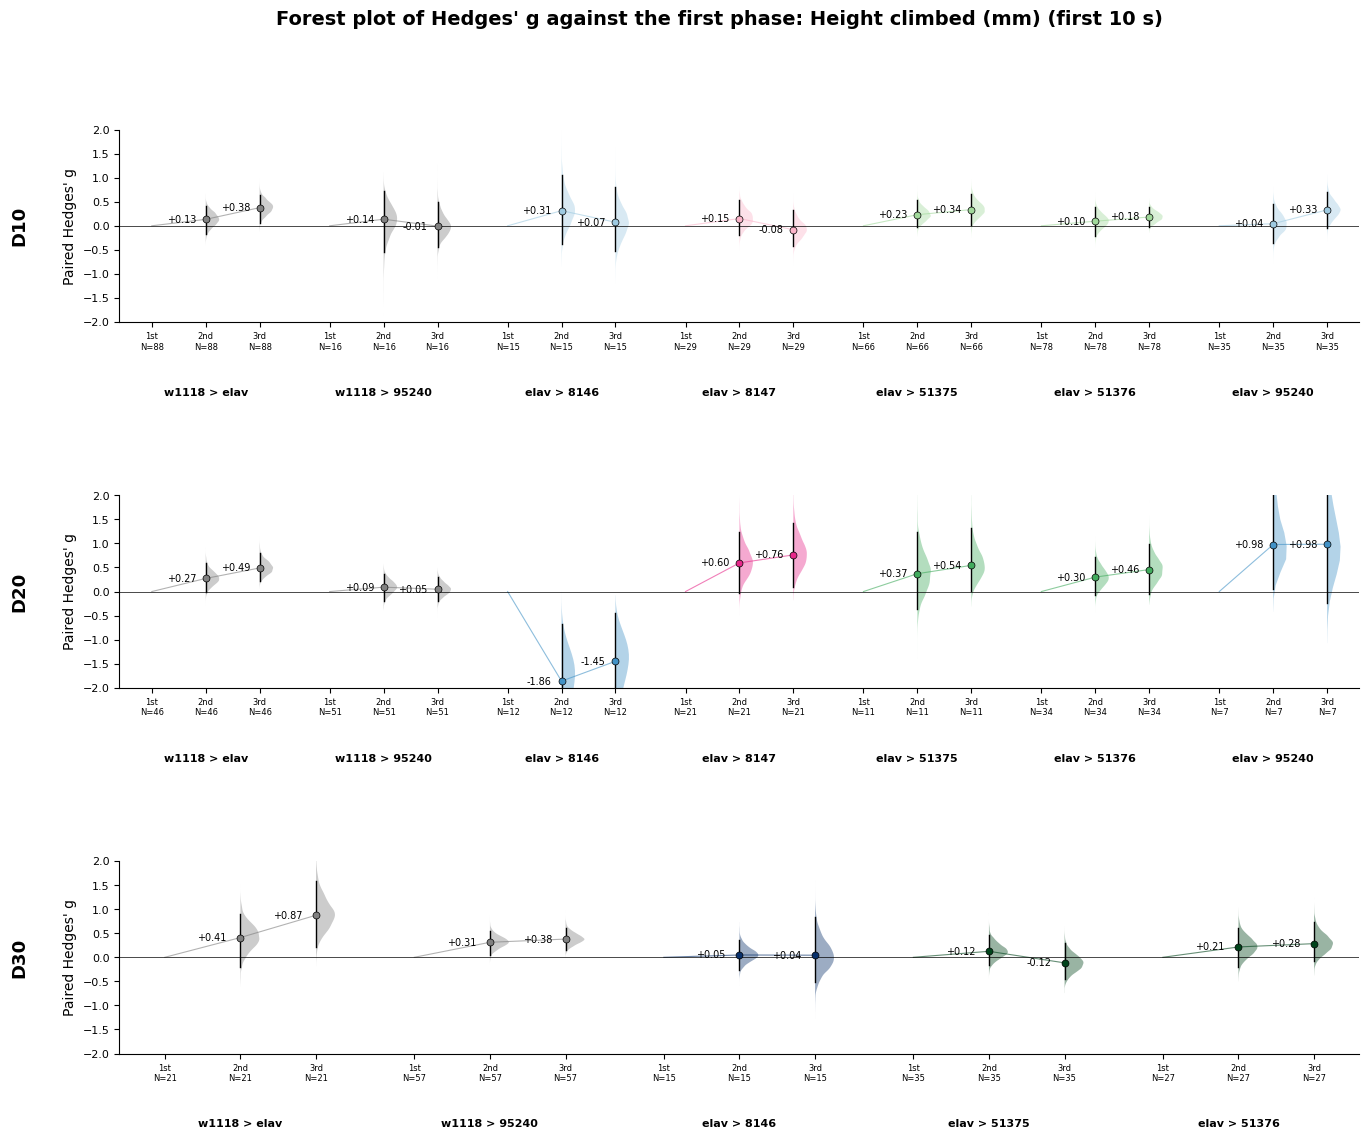

In [4]:
mpl.rcParams['svg.fonttype'] = 'none'

m = "Height"

contrastylims = {"Height": (-2, 2), "Speed": (-2, 2)}
gap = 0.3
ylabel = "Paired Hedges' g"

res = genotypecontrasts(m)
phasekeys = [phaselabels[n] for n in phase]

fig, axes = plt.subplots(len(ages), 1, figsize = (16, 12), gridspec_kw = {"hspace": 0.9})

for ax, age in zip(axes, ages):
    here = res[res.block == age]
    genos = [g for g in genotypelist(age) if g in set(here.genotype)]

    pos = {}
    x = 0.0
    for g in genos:
        for p in phasekeys:
            pos[(g, p)] = x
            x += 1
        x += gap

    ax.axhline(0, color = "black", lw = 0.5)
    ax.set_ylim(contrastylims[m])
    ax.set_xlim(-0.6, (max(pos.values()) if pos else 0) + 0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize = 8)

    for g in genos:
        colour = colourof(g, age)
        xs = [pos[(g, p)] for p in phasekeys]
        ys = []
        for p in phasekeys:
            row = here[(here.genotype == g) & (here.group == p)]
            d = row["difference"].iloc[0] if not row.empty else np.nan
            ys.append(0.0 if pd.isna(d) else d)
        ax.plot(xs, ys, color = colour, lw = 0.8, alpha = 0.6, zorder = 0)

    for _, r in here.dropna(subset = ["difference"]).iterrows():
        at = pos[(r["genotype"], r["group"])]
        colour = colourof(r["genotype"], age)

        parts = ax.violinplot(r["bootstraps"], positions = [at], widths = 0.5,
                              showextrema = False, showmedians = False)
        for pc in parts["bodies"]:
            v = pc.get_paths()[0].vertices
            v[:, 0] = np.clip(v[:, 0], np.mean(v[:, 0]), np.inf)
            pc.set_facecolor(colour)
            pc.set_alpha(0.4)

        ax.plot([at, at], [r["low"], r["high"]], color = "black", lw = 1, zorder = 1)
        ax.plot(at, r["difference"], "o", color = colour, markersize = 5, zorder = 2,
                markeredgecolor = "black", markeredgewidth = 0.5)
        ax.text(at - 0.18, r["difference"], "%+.2f" % r["difference"],
                ha = "right", va = "center", fontsize = 7)

    ns = here.set_index(["genotype", "group"])["N"]
    ax.set_xticks([pos[(g, p)] for g in genos for p in phasekeys])
    ax.set_xticklabels([p + ("\nN=" + str(int(ns[(g, p)])) if (g, p) in ns.index else "")
                        for g in genos for p in phasekeys], fontsize = 6)

    for g in genos:
        centre = np.mean([pos[(g, p)] for p in phasekeys])
        ax.text(centre, -0.34, g.replace(" x ", " > "), transform = ax.get_xaxis_transform(),
                ha = "center", va = "top", fontsize = 8, fontweight = "bold")

    ax.set_ylabel(ylabel, fontsize = 10)
    ax.text(-0.081, 0.5, age, transform = ax.transAxes, rotation = 90,
            ha = "center", va = "center", fontweight = "bold", fontsize = 13)

fig.suptitle("Forest plot of Hedges' g against the first phase: " + rawlabels[m] + " (first " + str(window) + " s)", fontweight = 'bold', fontsize = 14, y = 0.98)
#fig.savefig(savefiglocation + "Forest_" + str(window) + "s_phases_" + m + ".svg", bbox_inches='tight')

print(savefiglocation + "Forest_" + str(window) + "s_phases_" + m + ".svg")

elav x 8147 D30 is 4 flies, skipped
C:\Users\user\NUS Dropbox\acclab\Nicole M Lee\PD\Data Compilation\images\Forest_10s_phases_Speed.svg


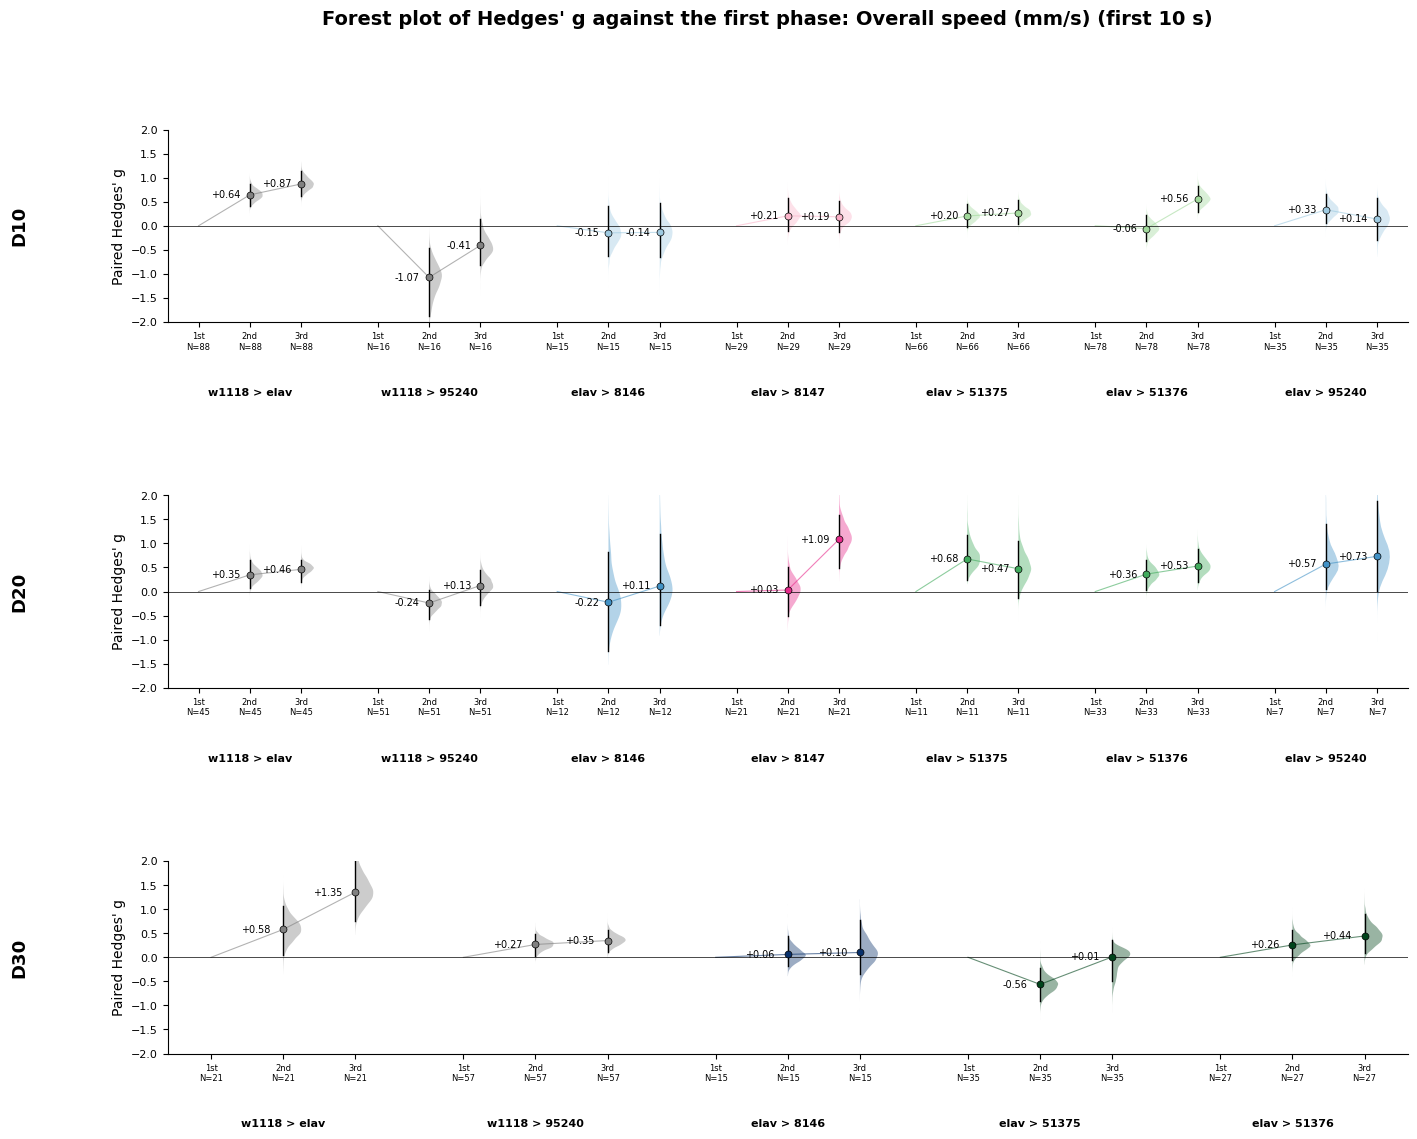

In [5]:
mpl.rcParams['svg.fonttype'] = 'none'

m = "Speed"

contrastylims = {"Height": (-2, 2), "Speed": (-2, 2)}
gap = 0.5
ylabel = "Paired Hedges' g"

res = genotypecontrasts(m)
phasekeys = [phaselabels[n] for n in phase]

fig, axes = plt.subplots(len(ages), 1, figsize = (16, 12), gridspec_kw = {"hspace": 0.9})

for ax, age in zip(axes, ages):
    here = res[res.block == age]
    genos = [g for g in genotypelist(age) if g in set(here.genotype)]

    pos = {}
    x = 0.0
    for g in genos:
        for p in phasekeys:
            pos[(g, p)] = x
            x += 1
        x += gap

    ax.axhline(0, color = "black", lw = 0.5)
    ax.set_ylim(contrastylims[m])
    ax.set_xlim(-0.6, (max(pos.values()) if pos else 0) + 0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize = 8)

    for g in genos:
        colour = colourof(g, age)
        xs = [pos[(g, p)] for p in phasekeys]
        ys = []
        for p in phasekeys:
            row = here[(here.genotype == g) & (here.group == p)]
            d = row["difference"].iloc[0] if not row.empty else np.nan
            ys.append(0.0 if pd.isna(d) else d)
        ax.plot(xs, ys, color = colour, lw = 0.8, alpha = 0.6, zorder = 0)

    for _, r in here.dropna(subset = ["difference"]).iterrows():
        at = pos[(r["genotype"], r["group"])]
        colour = colourof(r["genotype"], age)

        parts = ax.violinplot(r["bootstraps"], positions = [at], widths = 0.5,
                              showextrema = False, showmedians = False)
        for pc in parts["bodies"]:
            v = pc.get_paths()[0].vertices
            v[:, 0] = np.clip(v[:, 0], np.mean(v[:, 0]), np.inf)
            pc.set_facecolor(colour)
            pc.set_alpha(0.4)

        ax.plot([at, at], [r["low"], r["high"]], color = "black", lw = 1, zorder = 1)
        ax.plot(at, r["difference"], "o", color = colour, markersize = 5, zorder = 2,
                markeredgecolor = "black", markeredgewidth = 0.5)
        ax.text(at - 0.18, r["difference"], "%+.2f" % r["difference"],
                ha = "right", va = "center", fontsize = 7)

    ns = here.set_index(["genotype", "group"])["N"]
    ax.set_xticks([pos[(g, p)] for g in genos for p in phasekeys])
    ax.set_xticklabels([p + ("\nN=" + str(int(ns[(g, p)])) if (g, p) in ns.index else "")
                        for g in genos for p in phasekeys], fontsize = 6)

    for g in genos:
        centre = np.mean([pos[(g, p)] for p in phasekeys])
        ax.text(centre, -0.34, g.replace(" x ", " > "), transform = ax.get_xaxis_transform(),
                ha = "center", va = "top", fontsize = 8, fontweight = "bold")

    ax.set_ylabel(ylabel, fontsize = 10)
    ax.text(-0.12, 0.5, age, transform = ax.transAxes, rotation = 90,
            ha = "center", va = "center", fontweight = "bold", fontsize = 13)

fig.suptitle("Forest plot of Hedges' g against the first phase: " + rawlabels[m] + " (first " + str(window) + " s)", fontweight = 'bold', fontsize = 14, y = 0.98)
#fig.savefig(savefiglocation + "Forest_" + str(window) + "s_phases_" + m + ".svg", bbox_inches='tight')

print(savefiglocation + "Forest_" + str(window) + "s_phases_" + m + ".svg")

elav x 8147 D30 is 21 against 4 flies, skipped
C:\Users\user\NUS Dropbox\acclab\Nicole M Lee\PD\Data Compilation\images\Forest_10s_ages_Height.svg


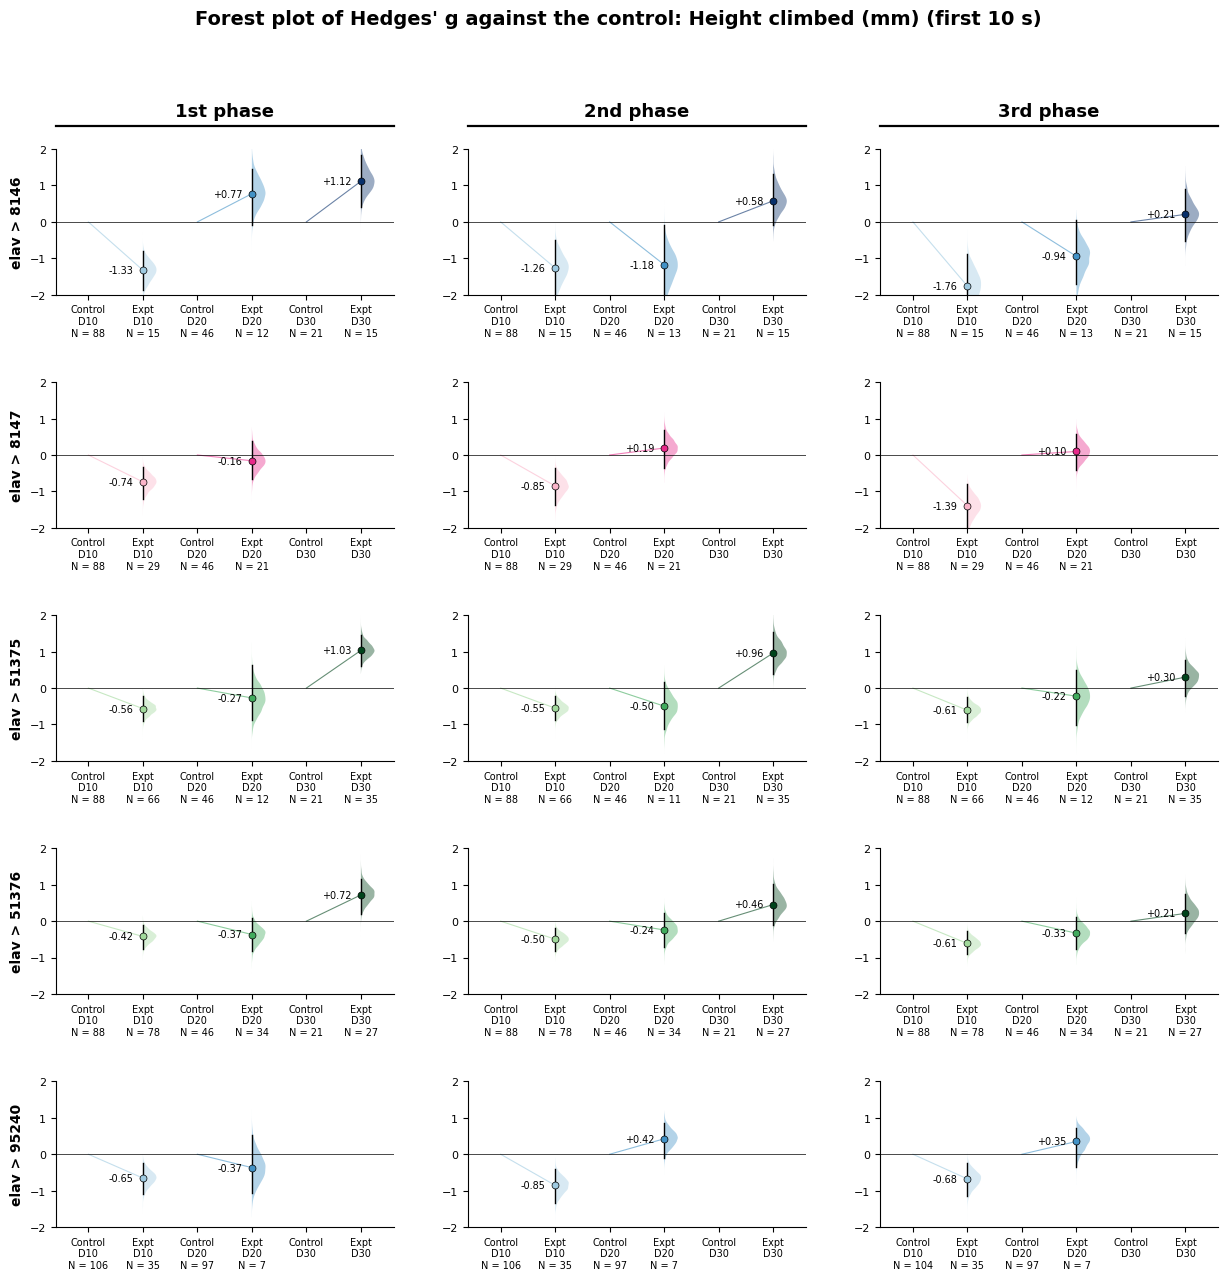

In [6]:
#PLOT 2 forest - Height

mpl.rcParams['svg.fonttype'] = 'none'

m = "Height"

#axis range, per metric. Edit these.
contrastylims = {"Height": (-2, 2), "Speed": (-2, 2)}

res = agecontrasts(m)
groups = [g + " " + a for a in ages for g in ["Control", "Expt"]]
blocks = phase

fig, axes = plt.subplots(len(crosses), len(blocks), figsize = (15, 14),
                         gridspec_kw = {"wspace": 0.22, "hspace": 0.6})

for row, cross in enumerate(crosses):
    for col, b in enumerate(blocks):
        ax = axes[row, col]
        here = res[(res.cross == cross) & (res.block == b)]

        ax.axhline(0, color = "black", lw = 0.5)
        ax.set_ylim(contrastylims[m])
        ax.set_xlim(-0.6, len(groups) - 0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(labelsize = 8)

        if here.empty:
            ax.set_xticks([])
            continue

        #the line from each control's baseline to its experimental, as plot 1 joins the phases
        for _, r in here.dropna(subset = ["difference"]).iterrows():
            at = groups.index(r["group"])
            ax.plot([at - 1, at], [0, r["difference"]], color = colourof(cross, r["group"].split(" ")[1]), lw = 0.8, alpha = 0.6, zorder = 0)

        for _, r in here.dropna(subset = ["difference"]).iterrows():
            at = groups.index(r["group"])
            colour = colourof(cross, r["group"].split(" ")[1]) if "Expt" in r["group"] else grey

            #the right half of the bootstrap distribution, clipped the way the DrosoClimb forest plot clips it
            parts = ax.violinplot(r["bootstraps"], positions = [at], widths = 0.5,
                                  showextrema = False, showmedians = False)
            for pc in parts["bodies"]:
                v = pc.get_paths()[0].vertices
                v[:, 0] = np.clip(v[:, 0], np.mean(v[:, 0]), np.inf)
                pc.set_facecolor(colour)
                pc.set_alpha(0.4)

            ax.plot([at, at], [r["low"], r["high"]], color = "black", lw = 1, zorder = 1)
            ax.plot(at, r["difference"], "o", color = colour, markersize = 5, zorder = 2,
                    markeredgecolor = "black", markeredgewidth = 0.5)
            ax.text(at - 0.18, r["difference"], "%+.2f" % r["difference"],
                    ha = "right", va = "center", fontsize = 7)

        ns = here.set_index("group")["N"]
        ax.set_xticks(range(len(groups)))
        ax.set_xticklabels([g.replace(" ", "\n") + ("\nN = " + str(ns[g]) if g in ns.index else "")
                            for g in groups], fontsize = 7)

    axes[row, 0].set_ylabel(cross.replace(" x ", " > "), fontweight = 'bold', fontsize = 10)

#the line over each column, and the block it spans. The only axis the genotypes share.
for col, b in enumerate(blocks):
    ax = axes[0, col]
    ax.plot([0, 1], [1.16, 1.16], transform = ax.transAxes, color = "k", lw = 1.6, clip_on = False)
    ax.text(0.5, 1.2, phaselabels[b] + " phase", transform = ax.transAxes, ha = "center", va = "bottom",
            fontsize = 13, fontweight = "bold")

fig.suptitle("Forest plot of Hedges' g against the control: " + rawlabels[m] + " (first " + str(window) + " s)", fontweight = 'bold', fontsize = 14, y = 0.98)
#fig.savefig(savefiglocation + "Forest_" + str(window) + "s_ages_" + m + ".svg", bbox_inches='tight')

print(savefiglocation + "Forest_" + str(window) + "s_ages_" + m + ".svg")

elav x 8147 D30 is 21 against 4 flies, skipped
C:\Users\user\NUS Dropbox\acclab\Nicole M Lee\PD\Data Compilation\images\Forest_10s_ages_Speed.svg


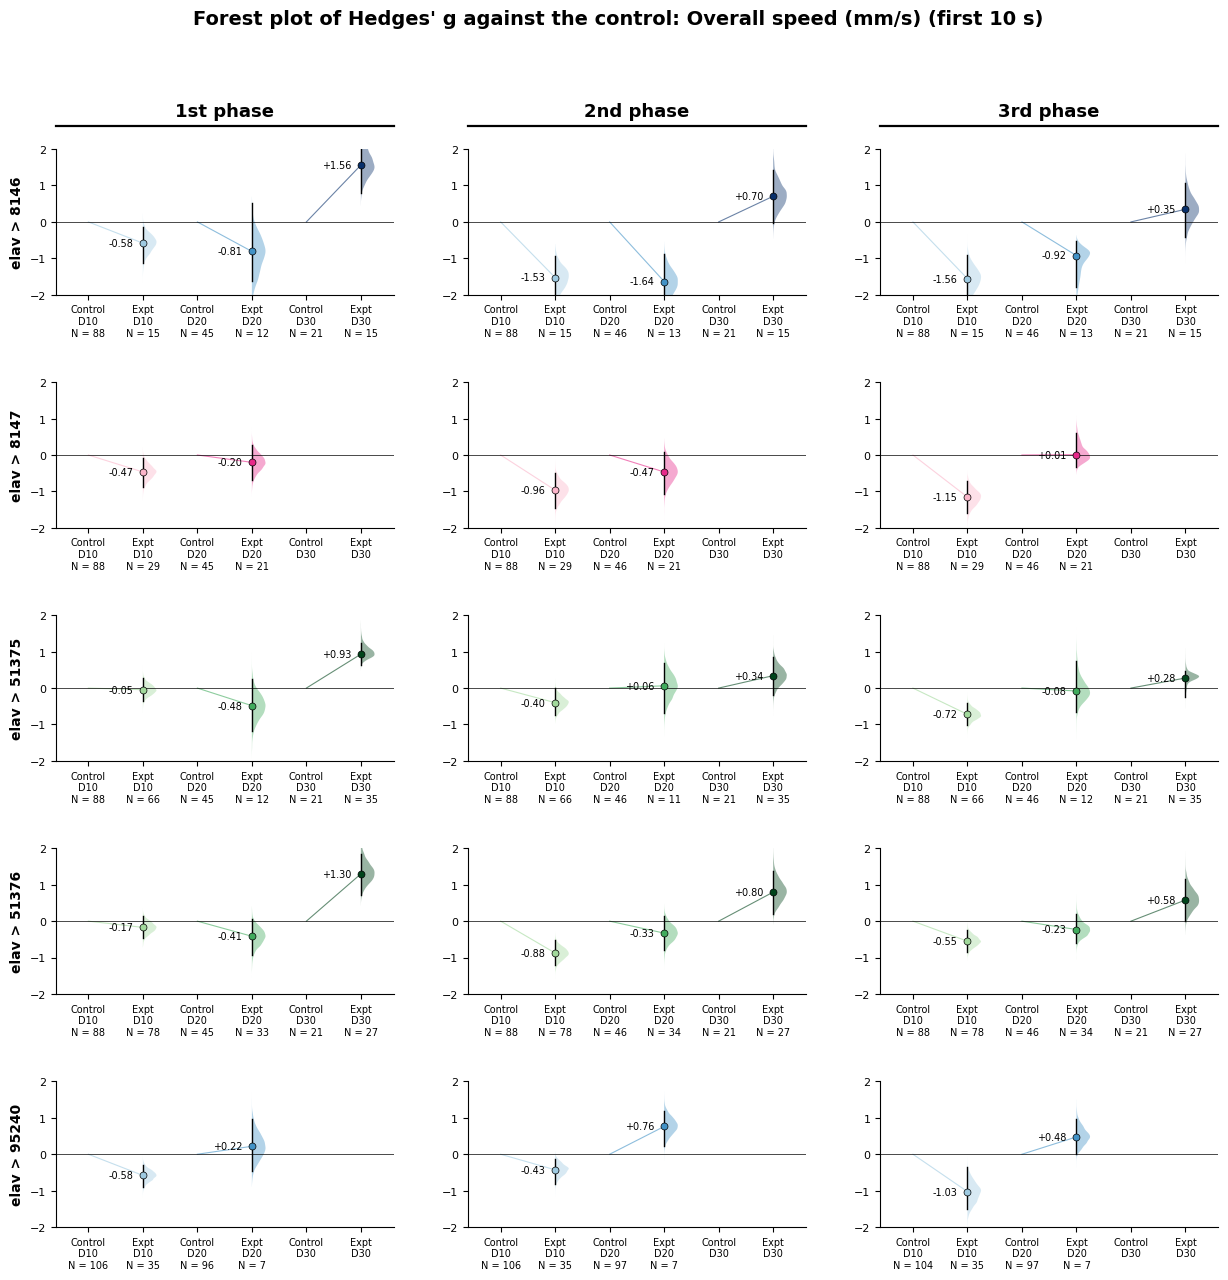

In [7]:
#PLOT 2 forest - Overall speed

mpl.rcParams['svg.fonttype'] = 'none'

m = "Speed"

#axis range, per metric. Edit these.
contrastylims = {"Height": (-2, 2), "Speed": (-2, 2)}

res = agecontrasts(m)
groups = [g + " " + a for a in ages for g in ["Control", "Expt"]]
blocks = phase

fig, axes = plt.subplots(len(crosses), len(blocks), figsize = (15, 14),
                         gridspec_kw = {"wspace": 0.22, "hspace": 0.6})

for row, cross in enumerate(crosses):
    for col, b in enumerate(blocks):
        ax = axes[row, col]
        here = res[(res.cross == cross) & (res.block == b)]

        ax.axhline(0, color = "black", lw = 0.5)
        ax.set_ylim(contrastylims[m])
        ax.set_xlim(-0.6, len(groups) - 0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(labelsize = 8)

        if here.empty:
            ax.set_xticks([])
            continue

        #the line from each control's baseline to its experimental, as plot 1 joins the phases
        for _, r in here.dropna(subset = ["difference"]).iterrows():
            at = groups.index(r["group"])
            ax.plot([at - 1, at], [0, r["difference"]], color = colourof(cross, r["group"].split(" ")[1]), lw = 0.8, alpha = 0.6, zorder = 0)

        for _, r in here.dropna(subset = ["difference"]).iterrows():
            at = groups.index(r["group"])
            colour = colourof(cross, r["group"].split(" ")[1]) if "Expt" in r["group"] else grey

            #the right half of the bootstrap distribution, clipped the way the DrosoClimb forest plot clips it
            parts = ax.violinplot(r["bootstraps"], positions = [at], widths = 0.5,
                                  showextrema = False, showmedians = False)
            for pc in parts["bodies"]:
                v = pc.get_paths()[0].vertices
                v[:, 0] = np.clip(v[:, 0], np.mean(v[:, 0]), np.inf)
                pc.set_facecolor(colour)
                pc.set_alpha(0.4)

            ax.plot([at, at], [r["low"], r["high"]], color = "black", lw = 1, zorder = 1)
            ax.plot(at, r["difference"], "o", color = colour, markersize = 5, zorder = 2,
                    markeredgecolor = "black", markeredgewidth = 0.5)
            ax.text(at - 0.18, r["difference"], "%+.2f" % r["difference"],
                    ha = "right", va = "center", fontsize = 7)

        ns = here.set_index("group")["N"]
        ax.set_xticks(range(len(groups)))
        ax.set_xticklabels([g.replace(" ", "\n") + ("\nN = " + str(ns[g]) if g in ns.index else "")
                            for g in groups], fontsize = 7)

    axes[row, 0].set_ylabel(cross.replace(" x ", " > "), fontweight = 'bold', fontsize = 10)

#the line over each column, and the block it spans. The only axis the genotypes share.
for col, b in enumerate(blocks):
    ax = axes[0, col]
    ax.plot([0, 1], [1.16, 1.16], transform = ax.transAxes, color = "k", lw = 1.6, clip_on = False)
    ax.text(0.5, 1.2, phaselabels[b] + " phase", transform = ax.transAxes, ha = "center", va = "bottom",
            fontsize = 13, fontweight = "bold")

fig.suptitle("Forest plot of Hedges' g against the control: " + rawlabels[m] + " (first " + str(window) + " s)", fontweight = 'bold', fontsize = 14, y = 0.98)
#fig.savefig(savefiglocation + "Forest_" + str(window) + "s_ages_" + m + ".svg", bbox_inches='tight')

print(savefiglocation + "Forest_" + str(window) + "s_ages_" + m + ".svg")